# Audit Independen BiGRU dan GRU pada IHSG

Notebook Kaggle ini menguji apakah BiGRU memprediksi penutupan IHSG hari berikutnya tanpa membaca target atau informasi setelah waktu prediksi. Eksperimen memakai simbol `^JKSE`, jendela historis 30 hari bursa, target `Close(t+1)`, split kronologis, scaler yang hanya di-fit pada data latih, dan kontrol pelatihan yang sama untuk GRU serta BiGRU.

**Keputusan audit tidak didasarkan pada akurasi tunggal.** Status akhir ditentukan dari bukti alignment waktu, sumber statistik normalisasi, bentuk tensor, kestabilan lintas seed, dan besar penurunan kinerja ketika arah backward dimatikan.

## 1. Algoritma Program

1. Tetapkan periode data, fitur, horizon, panjang jendela, seed, dan batas split sebelum melihat hasil.
2. Unduh OHLCV IHSG atau baca CSV Kaggle, lalu standarkan nama kolom dan tanggal.
3. Audit duplikasi, nilai hilang, urutan waktu, harga tidak logis, dan cakupan periode.
4. Bentuk fitur kausal dari data hingga hari `t`; bentuk target harga penutupan pada `t+1`.
5. Bagi sampel berdasarkan **tanggal target**, bukan posisi acak.
6. Fit scaler fitur dan target hanya pada baris latih.
7. Bentuk tensor `[sampel, 30 hari, fitur]` dan simpan tanggal awal, tanggal akhir input, serta tanggal target.
8. Jalankan tes keras: `akhir_input < tanggal_target`, fitur tidak mengandung target, scaler tidak memakai validasi/uji, dan split tidak tumpang tindih.
9. Latih GRU dan BiGRU dengan data, seed, optimizer, batch, epoch maksimum, patience, dan prosedur evaluasi yang sama.
10. Hitung MAE, RMSE, MAPE, R2, waktu latih, jumlah parameter, dan stabilitas lintas seed.
11. Nilai bukti teknis dan terbitkan memo integritas: **VALID**, **MERAGUKAN**, atau **TIDAK SAH**.

In [1]:
import pandas as pd
algoritma = pd.DataFrame({
    "Tahap": range(1, 11),
    "Kontrol utama": ["Praregistrasi", "Akuisisi", "Kualitas", "Fitur t dan target t+1", "Split target-date", "Scaler train-only", "Sequence", "Tensor audit", "Ablasi GRU", "Memo integritas"]
})
display(algoritma.style.hide(axis="index").set_caption("OUTPUT 1 — Peta algoritma audit"))

Tahap,Kontrol utama
1,Praregistrasi
2,Akuisisi
3,Kualitas
4,Fitur t dan target t+1
5,Split target-date
6,Scaler train-only
7,Sequence
8,Tensor audit
9,Ablasi GRU
10,Memo integritas


## 2. Pseudocode

```text
KUNCI konfigurasi eksperimen
MUAT dan URUTKAN data IHSG berdasarkan tanggal
JIKA data gagal audit kualitas: HENTIKAN

UNTUK setiap baris waktu t:
    HITUNG fitur hanya dari observasi sampai t
    SET target = Close pada t+1

SPLIT berdasarkan tanggal target menjadi train, validation, test
FIT scaler_X dan scaler_y hanya menggunakan train
TRANSFORM validation dan test tanpa refit

UNTUK setiap sampel:
    X = fitur dari t-29 sampai t
    y = Close(t+1)
    SIMPAN start_date, end_date, target_date

ASSERT end_date < target_date untuk semua sampel
ASSERT kolom target tidak ada dalam tensor fitur
ASSERT seluruh statistik scaler berasal dari train

UNTUK seed dalam daftar seed:
    LATIH GRU dan BiGRU dengan kontrol identik
    PREDIKSI test yang sama
    HITUNG metrik dan simpan riwayat pelatihan

BANDINGKAN rerata dan simpangan baku
JIKA ada target/future pada input: TIDAK SAH
ELSE JIKA kontrol gagal atau hasil sangat tidak stabil: MERAGUKAN
ELSE: VALID
```

In [2]:
pseudo_checks = pd.DataFrame([
    ["Input berakhir pada t", "end_input < target_date", "Wajib"],
    ["Target berada pada t+1", "target_date = next trading row", "Wajib"],
    ["Scaler train-only", "fit_end <= train_end", "Wajib"],
    ["Kontrol model sama", "seed/split/batch/epoch identik", "Wajib"],
    ["Uji ulang", ">= 3 seed", "Wajib"],
], columns=["Bukti", "Tes", "Status"])
display(pseudo_checks.style.hide(axis="index").set_caption("OUTPUT 2 — Pseudocode menjadi kontrol audit"))

Bukti,Tes,Status
Input berakhir pada t,end_input < target_date,Wajib
Target berada pada t+1,target_date = next trading row,Wajib
Scaler train-only,fit_end <= train_end,Wajib
Kontrol model sama,seed/split/batch/epoch identik,Wajib
Uji ulang,>= 3 seed,Wajib


## 3. Lingkungan dan Konfigurasi

In [3]:
!pip -q install "yfinance>=0.2.54"

import os, time, random, warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED_LIST = [17, 42, 81]
START_DATE, END_EXCLUSIVE = "2015-01-01", "2026-01-10"
TRAIN_TARGET_END = pd.Timestamp("2023-12-31")
VAL_TARGET_END = pd.Timestamp("2024-12-31")
TEST_TARGET_END = pd.Timestamp("2025-12-31")
LOOKBACK, HORIZON = 30, 1
UNITS, BATCH_SIZE, MAX_EPOCHS, PATIENCE = 32, 32, 80, 10
CSV_PATH = ""  # opsional: path file CSV dari Add Input Kaggle

config = pd.DataFrame({"Parameter":["Rentang", "Train target", "Validasi target", "Uji target", "Lookback", "Horizon", "Seed", "Unit", "Batch", "Epoch maksimum"],
                       "Nilai":[f"{START_DATE} s.d. 2025", str(TRAIN_TARGET_END.date()), str(VAL_TARGET_END.date()), str(TEST_TARGET_END.date()), LOOKBACK, HORIZON, str(SEED_LIST), UNITS, BATCH_SIZE, MAX_EPOCHS]})
display(config.style.hide(axis="index").set_caption("OUTPUT 3 — Konfigurasi yang dikunci"))

Parameter,Nilai
Rentang,2015-01-01 s.d. 2025
Train target,2023-12-31
Validasi target,2024-12-31
Uji target,2025-12-31
Lookback,30
Horizon,1
Seed,"[17, 42, 81]"
Unit,32
Batch,32
Epoch maksimum,80


## 4. Akuisisi dan Standardisasi Data

Date,Open,High,Low,Close,Volume
2015-01-02 00:00:00,5233.795898,5247.937988,5230.750000,5242.769043,38133000
2015-01-05 00:00:00,5229.684082,5233.660156,5206.285156,5219.995117,44846100
2015-01-06 00:00:00,5186.204102,5194.803223,5169.060059,5169.060059,51516500
2015-01-07 00:00:00,5175.554199,5207.375977,5174.795898,5207.118164,72088500
2015-01-08 00:00:00,5218.399902,5230.179199,5208.993164,5211.828125,69163000


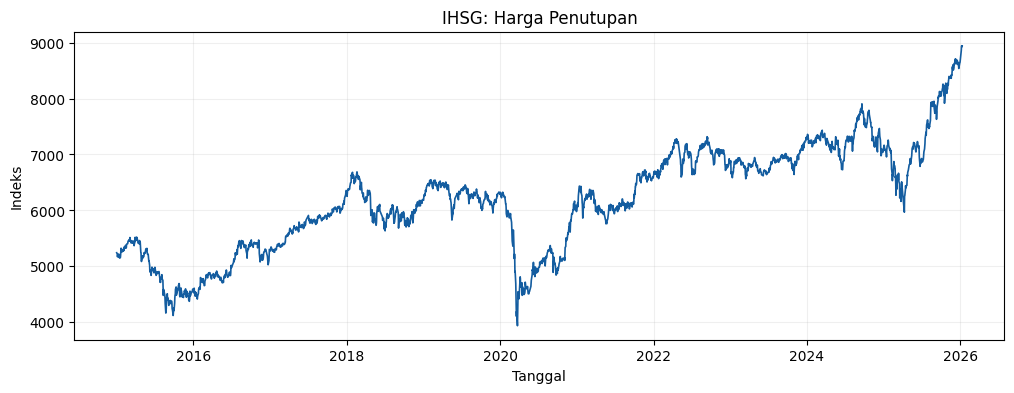

In [4]:
def standardize_ohlcv(raw):
    x = raw.copy()
    if isinstance(x.columns, pd.MultiIndex):
        x.columns = [str(c[0]) for c in x.columns]
    x = x.reset_index() if "Date" not in x.columns else x
    aliases = {str(c).strip().lower(): c for c in x.columns}
    rename = {}
    for want in ["date", "open", "high", "low", "close", "volume"]:
        if want in aliases: rename[aliases[want]] = want.title()
    x = x.rename(columns=rename)
    required = ["Date", "Open", "High", "Low", "Close", "Volume"]
    missing = [c for c in required if c not in x.columns]
    if missing: raise ValueError(f"Kolom wajib tidak ditemukan: {missing}")
    x = x[required].copy()
    x["Date"] = pd.to_datetime(x["Date"], errors="coerce").dt.tz_localize(None)
    for c in required[1:]: x[c] = pd.to_numeric(x[c], errors="coerce")
    return x.dropna(subset=["Date"]).sort_values("Date").drop_duplicates("Date").reset_index(drop=True)

source = "Yahoo Finance"
try:
    raw = yf.download("^JKSE", start=START_DATE, end=END_EXCLUSIVE, auto_adjust=False, progress=False, threads=False)
    if raw.empty: raise ValueError("Yahoo Finance mengembalikan data kosong")
    df = standardize_ohlcv(raw)
except Exception as err:
    if not CSV_PATH or not os.path.exists(CSV_PATH):
        raise RuntimeError(f"Unduhan gagal: {err}. Aktifkan Internet Kaggle atau isi CSV_PATH.")
    source = f"CSV: {CSV_PATH}"
    df = standardize_ohlcv(pd.read_csv(CSV_PATH))

display(df.head().style.hide(axis="index").set_caption(f"OUTPUT 4A — Sampel data ({source})"))
fig, ax = plt.subplots(figsize=(12,4)); ax.plot(df.Date, df.Close, color="#145DA0", lw=1.2); ax.set(title="IHSG: Harga Penutupan", xlabel="Tanggal", ylabel="Indeks"); ax.grid(alpha=.2); plt.show()

## 5. Audit Kualitas Data

In [5]:
quality = pd.DataFrame([
    ["Jumlah baris", len(df), len(df) >= 2000],
    ["Tanggal unik", df.Date.nunique(), df.Date.is_unique],
    ["Urutan meningkat", bool(df.Date.is_monotonic_increasing), df.Date.is_monotonic_increasing],
    ["Nilai hilang OHLCV", int(df[["Open","High","Low","Close","Volume"]].isna().sum().sum()), df[["Open","High","Low","Close","Volume"]].notna().all().all()],
    ["Harga positif", bool((df[["Open","High","Low","Close"]] > 0).all().all()), (df[["Open","High","Low","Close"]] > 0).all().all()],
    ["High >= Low", bool((df.High >= df.Low).all()), (df.High >= df.Low).all()],
    ["Data uji 2025 tersedia", int(df.Date.dt.year.eq(2025).sum()), df.Date.dt.year.eq(2025).sum() >= 180],
], columns=["Pemeriksaan", "Nilai", "Lulus"])
display(quality.style.hide(axis="index").applymap(lambda v: "background:#DFF2BF" if v is True else ("background:#FFD2D2" if v is False else ""), subset=["Lulus"]).set_caption("OUTPUT 5 — Audit kualitas"))
if not quality.Lulus.all(): raise AssertionError("Audit kualitas gagal. Periksa tabel sebelum melanjutkan.")

Pemeriksaan,Nilai,Lulus
Jumlah baris,2667,True
Tanggal unik,2667,True
Urutan meningkat,True,True
Nilai hilang OHLCV,0,True
Harga positif,True,True
High >= Low,True,True
Data uji 2025 tersedia,236,True


## 6. Fitur Kausal dan Target t+1

Date,Close,Target_Date,Target_Close
2025-12-24 00:00:00,"8,537.91",2025-12-29 00:00:00,"8,644.26"
2025-12-29 00:00:00,"8,644.26",2025-12-30 00:00:00,"8,646.94"
2025-12-30 00:00:00,"8,646.94",2026-01-02 00:00:00,"8,748.13"
2026-01-02 00:00:00,"8,748.13",2026-01-05 00:00:00,"8,859.19"
2026-01-05 00:00:00,"8,859.19",2026-01-06 00:00:00,"8,933.61"
2026-01-06 00:00:00,"8,933.61",2026-01-07 00:00:00,"8,944.81"
2026-01-07 00:00:00,"8,944.81",2026-01-08 00:00:00,"8,925.47"
2026-01-08 00:00:00,"8,925.47",2026-01-09 00:00:00,"8,936.75"


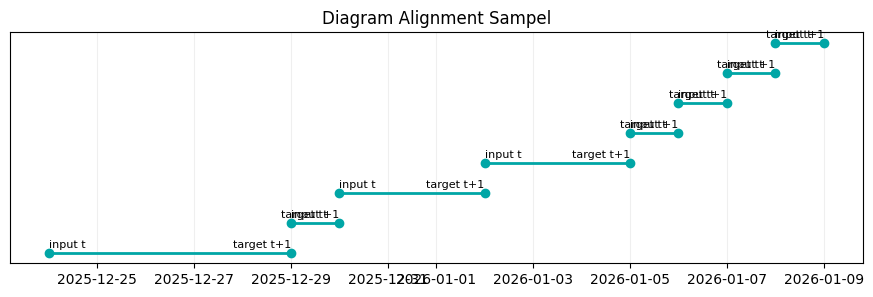

In [6]:
d = df.copy()
d["Return_1"] = d.Close.pct_change()
d["Range"] = (d.High - d.Low) / d.Close
d["OC_Return"] = (d.Close - d.Open) / d.Open
d["MA5_Ratio"] = d.Close / d.Close.rolling(5).mean() - 1
d["MA20_Ratio"] = d.Close / d.Close.rolling(20).mean() - 1
d["Volatility10"] = d.Return_1.rolling(10).std()
d["Volume_Change"] = d.Volume.pct_change().replace([np.inf,-np.inf], np.nan)
d["Target_Close"] = d.Close.shift(-HORIZON)
d["Target_Date"] = d.Date.shift(-HORIZON)
FEATURES = ["Close","Return_1","Range","OC_Return","MA5_Ratio","MA20_Ratio","Volatility10","Volume_Change"]
model_df = d[["Date","Target_Date","Target_Close"] + FEATURES].replace([np.inf,-np.inf], np.nan).dropna().reset_index(drop=True)

alignment_sample = model_df[["Date","Close","Target_Date","Target_Close"]].tail(8)
display(alignment_sample.style.hide(axis="index").format({"Close":"{:,.2f}","Target_Close":"{:,.2f}"}).set_caption("OUTPUT 6A — Bukti alignment t ke t+1"))
fig, ax = plt.subplots(figsize=(11,3));
for y,(a,b) in enumerate(zip(alignment_sample.Date, alignment_sample.Target_Date)):
    ax.plot([a,b],[y,y],"o-",color="#00A6A6",lw=2); ax.text(a,y+.15,"input t",ha="left",fontsize=8); ax.text(b,y+.15,"target t+1",ha="right",fontsize=8)
ax.set_yticks([]); ax.set_title("Diagram Alignment Sampel"); ax.grid(axis="x",alpha=.2); plt.show()

## 7. Split Kronologis dan Normalisasi Train-Only

In [7]:
split = np.select([model_df.Target_Date <= TRAIN_TARGET_END,
                   model_df.Target_Date <= VAL_TARGET_END,
                   model_df.Target_Date <= TEST_TARGET_END], ["train","validation","test"], default="outside")
model_df["Split"] = split
model_df = model_df[model_df.Split != "outside"].reset_index(drop=True)
train_rows = model_df.Split.eq("train")
x_scaler, y_scaler = StandardScaler(), StandardScaler()
x_scaler.fit(model_df.loc[train_rows, FEATURES])
y_scaler.fit(model_df.loc[train_rows, ["Target_Close"]])
X_all = x_scaler.transform(model_df[FEATURES]).astype("float32")
y_all = y_scaler.transform(model_df[["Target_Close"]]).ravel().astype("float32")

split_table = model_df.groupby("Split", sort=False).agg(Jumlah=("Date","size"), Awal_input=("Date","min"), Akhir_target=("Target_Date","max")).reset_index()
display(split_table.style.hide(axis="index").set_caption("OUTPUT 7A — Split berdasarkan tanggal target"))
scaler_audit = pd.DataFrame({"Fitur":FEATURES,"Mean_train":x_scaler.mean_,"Scale_train":x_scaler.scale_,"Fit_end":[model_df.loc[train_rows,"Date"].max()]*len(FEATURES)})
display(scaler_audit.style.hide(axis="index").format({"Mean_train":"{:.5f}","Scale_train":"{:.5f}"}).set_caption("OUTPUT 7B — Statistik scaler dari train"))

Split,Jumlah,Awal_input,Akhir_target
train,2160,2015-01-29 00:00:00,2023-12-29 00:00:00
validation,237,2023-12-29 00:00:00,2024-12-30 00:00:00
test,236,2024-12-30 00:00:00,2025-12-30 00:00:00


Fitur,Mean_train,Scale_train,Fit_end
Close,5933.41312,772.44297,2023-12-28 00:00:00
Return_1,0.00021,0.00964,2023-12-28 00:00:00
Range,0.01079,0.00719,2023-12-28 00:00:00
OC_Return,-0.00022,0.00860,2023-12-28 00:00:00
MA5_Ratio,0.00035,0.01063,2023-12-28 00:00:00
MA20_Ratio,0.00158,0.02367,2023-12-28 00:00:00
Volatility10,0.00839,0.00479,2023-12-28 00:00:00
Volume_Change,0.54013,7.11087,2023-12-28 00:00:00


## 8. Pembentukan Sequence dan Audit Tensor

In [8]:
def make_sequences(X, y, frame, lookback):
    xs, ys, meta = [], [], []
    for i in range(lookback-1, len(frame)):
        xs.append(X[i-lookback+1:i+1]); ys.append(y[i])
        meta.append((frame.Date.iloc[i-lookback+1], frame.Date.iloc[i], frame.Target_Date.iloc[i], frame.Split.iloc[i]))
    return np.asarray(xs), np.asarray(ys), pd.DataFrame(meta, columns=["Input_Start","Input_End","Target_Date","Split"])

X_seq, y_seq, seq_meta = make_sequences(X_all, y_all, model_df, LOOKBACK)
masks = {s: seq_meta.Split.eq(s).to_numpy() for s in ["train","validation","test"]}
tensor_table = pd.DataFrame([[s, list(X_seq[m].shape), list(y_seq[m].shape), seq_meta.loc[m,"Input_End"].min(), seq_meta.loc[m,"Target_Date"].max()] for s,m in masks.items()], columns=["Split","X shape","y shape","Input_end_min","Target_max"])
display(tensor_table.style.hide(axis="index").set_caption("OUTPUT 8A — Bentuk tensor"))

tensor_checks = pd.DataFrame([
 ["Semua input berakhir sebelum target", bool((seq_meta.Input_End < seq_meta.Target_Date).all())],
 ["Target tidak menjadi fitur", "Target_Close" not in FEATURES and "Target_Date" not in FEATURES],
 ["Tidak ada NaN tensor", bool(np.isfinite(X_seq).all() and np.isfinite(y_seq).all())],
 ["Train dan test tidak tumpang tindih", seq_meta.loc[masks["train"],"Target_Date"].max() < seq_meta.loc[masks["test"],"Target_Date"].min()],
 ["Scaler fit berakhir di train", model_df.loc[train_rows,"Date"].max() <= TRAIN_TARGET_END],
], columns=["Tes integritas", "Lulus"])
display(tensor_checks.style.hide(axis="index").applymap(lambda v:"background:#DFF2BF" if v is True else "background:#FFD2D2", subset=["Lulus"]).set_caption("OUTPUT 8B — Pemeriksaan tensor"))
if not tensor_checks.Lulus.all(): raise AssertionError("DATA LEAKAGE atau kesalahan alignment terdeteksi.")

Split,X shape,y shape,Input_end_min,Target_max
train,"[2131, 30, 8]",[2131],2015-03-12 00:00:00,2023-12-29 00:00:00
validation,"[237, 30, 8]",[237],2023-12-29 00:00:00,2024-12-30 00:00:00
test,"[236, 30, 8]",[236],2024-12-30 00:00:00,2025-12-30 00:00:00


Tes integritas,Lulus
Semua input berakhir sebelum target,True
Target tidak menjadi fitur,True
Tidak ada NaN tensor,True
Train dan test tidak tumpang tindih,True
Scaler fit berakhir di train,True


## 9. Model GRU dan BiGRU dengan Kontrol Identik

In [9]:
def set_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed); random.seed(seed); np.random.seed(seed); tf.keras.utils.set_random_seed(seed)
    try: tf.config.experimental.enable_op_determinism()
    except Exception: pass

def build_model(kind, input_shape):
    inp = tf.keras.Input(shape=input_shape)
    layer = tf.keras.layers.GRU(UNITS, dropout=0.10)
    x = tf.keras.layers.Bidirectional(layer, merge_mode="concat", name="BiGRU")(inp) if kind == "BiGRU" else layer(inp)
    x = tf.keras.layers.Dense(16, activation="relu")(x)
    out = tf.keras.layers.Dense(1)(x)
    model = tf.keras.Model(inp, out, name=kind)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return model

control = pd.DataFrame({"Kontrol":["Input", "Target", "Train/validation/test", "Seed", "Optimizer", "Learning rate", "Batch", "Epoch", "Early stopping"],
                        "GRU":[str(X_seq.shape[1:]),"Close t+1","Identik",str(SEED_LIST),"Adam",.001,BATCH_SIZE,MAX_EPOCHS,PATIENCE],
                        "BiGRU":[str(X_seq.shape[1:]),"Close t+1","Identik",str(SEED_LIST),"Adam",.001,BATCH_SIZE,MAX_EPOCHS,PATIENCE]})
display(control.style.hide(axis="index").set_caption("OUTPUT 9 — Matriks kontrol eksperimen"))

Kontrol,GRU,BiGRU
Input,"(30, 8)","(30, 8)"
Target,Close t+1,Close t+1
Train/validation/test,Identik,Identik
Seed,"[17, 42, 81]","[17, 42, 81]"
Optimizer,Adam,Adam
Learning rate,0.001000,0.001000
Batch,32,32
Epoch,80,80
Early stopping,10,10


## 10. Pelatihan, Uji Ulang, dan Prediksi

In [10]:
Xtr,ytr = X_seq[masks["train"]],y_seq[masks["train"]]
Xv,yv = X_seq[masks["validation"]],y_seq[masks["validation"]]
Xte,yte = X_seq[masks["test"]],y_seq[masks["test"]]
test_dates = seq_meta.loc[masks["test"],"Target_Date"].reset_index(drop=True)
actual = y_scaler.inverse_transform(yte.reshape(-1,1)).ravel()
rows, predictions, histories = [], [], {}

def mape_safe(a,p):
    den = np.maximum(np.abs(a), 1e-8)
    return float(np.mean(np.abs((a-p)/den))*100)

for kind in ["GRU","BiGRU"]:
    for seed in SEED_LIST:
        tf.keras.backend.clear_session(); set_seed(seed)
        model = build_model(kind, Xtr.shape[1:])
        cb = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
        t0=time.perf_counter()
        hist=model.fit(Xtr,ytr,validation_data=(Xv,yv),epochs=MAX_EPOCHS,batch_size=BATCH_SIZE,shuffle=False,verbose=0,callbacks=[cb])
        seconds=time.perf_counter()-t0
        pred_scaled=model.predict(Xte,verbose=0).ravel()
        pred=y_scaler.inverse_transform(pred_scaled.reshape(-1,1)).ravel()
        if len(pred)!=len(actual) or not np.isfinite(pred).all(): raise AssertionError(f"Prediksi {kind} seed {seed} tidak valid")
        rows.append([kind,seed,len(hist.history["loss"]),model.count_params(),seconds,mean_absolute_error(actual,pred),mean_squared_error(actual,pred)**.5,mape_safe(actual,pred),r2_score(actual,pred)])
        predictions.append(pd.DataFrame({"Date":test_dates,"Actual":actual,"Prediction":pred,"Model":kind,"Seed":seed}))
        histories[(kind,seed)] = hist.history

run_metrics=pd.DataFrame(rows,columns=["Model","Seed","Epoch","Parameters","Train_seconds","MAE","RMSE","MAPE_pct","R2"])
display(run_metrics.style.hide(axis="index").format({"Train_seconds":"{:.1f}","MAE":"{:.2f}","RMSE":"{:.2f}","MAPE_pct":"{:.3f}","R2":"{:.4f}"}).set_caption("OUTPUT 10 — Metrik setiap uji ulang"))

I0000 00:00:1785515954.622081      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
2026-07-31 16:39:16.066731: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-07-31 16:39:36.142649: E tensorflow/core/framework/node_

2026-07-31 16:40:15.648968: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2026-07-31 16:40:25.091537: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-07-31 16:40:46.548004: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Model,Seed,Epoch,Parameters,Train_seconds,MAE,RMSE,MAPE_pct,R2
GRU,17,39,4577,20.1,308.76,403.10,3.981,0.6930
GRU,42,50,4577,23.0,291.39,380.46,3.772,0.7265
GRU,81,32,4577,15.3,295.86,382.93,3.829,0.7229
BiGRU,17,12,9121,8.8,277.90,347.62,3.556,0.7717
BiGRU,42,33,9121,20.7,193.93,242.84,2.541,0.8886
BiGRU,81,24,9121,15.5,256.15,329.96,3.268,0.7943


## 11. Konvergensi dan Stabilitas Lintas Seed

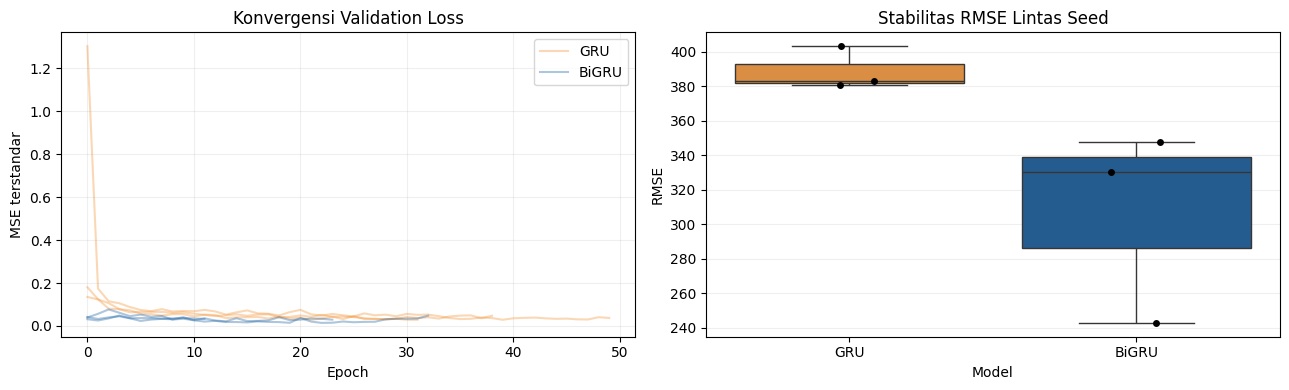

Model,RMSE_mean,RMSE_std,MAE_mean,MAPE_mean,R2_mean,Time_mean,Parameters
BiGRU,306.8070,56.0947,242.6609,3.1218,0.8182,14.9995,9121
GRU,388.8303,12.4221,298.6737,3.8604,0.7142,19.4818,4577


In [11]:
fig, axes=plt.subplots(1,2,figsize=(13,4))
colors={"GRU":"#F28E2B","BiGRU":"#145DA0"}
for (kind,seed),h in histories.items(): axes[0].plot(h["val_loss"],color=colors[kind],alpha=.35,label=kind if seed==SEED_LIST[0] else None)
axes[0].set(title="Konvergensi Validation Loss",xlabel="Epoch",ylabel="MSE terstandar"); axes[0].legend(); axes[0].grid(alpha=.2)
sns.boxplot(data=run_metrics,x="Model",y="RMSE",palette=colors,ax=axes[1]); sns.stripplot(data=run_metrics,x="Model",y="RMSE",color="black",size=5,ax=axes[1]); axes[1].set_title("Stabilitas RMSE Lintas Seed"); axes[1].grid(axis="y",alpha=.2); plt.tight_layout(); plt.show()

summary=run_metrics.groupby("Model").agg(RMSE_mean=("RMSE","mean"),RMSE_std=("RMSE","std"),MAE_mean=("MAE","mean"),MAPE_mean=("MAPE_pct","mean"),R2_mean=("R2","mean"),Time_mean=("Train_seconds","mean"),Parameters=("Parameters","first")).reset_index()
display(summary.style.hide(axis="index").format({c:"{:.4f}" for c in ["RMSE_mean","RMSE_std","MAE_mean","MAPE_mean","R2_mean","Time_mean"]}).set_caption("OUTPUT 11 — Ringkasan stabilitas"))

## 12. Alignment Prediksi dan Perbandingan Visual

Pemeriksaan alignment,Lulus
Jumlah tanggal per run sama,True
Tanggal unik per run,True
Aktual identik antarrun,True
Tidak ada prediksi kosong,True


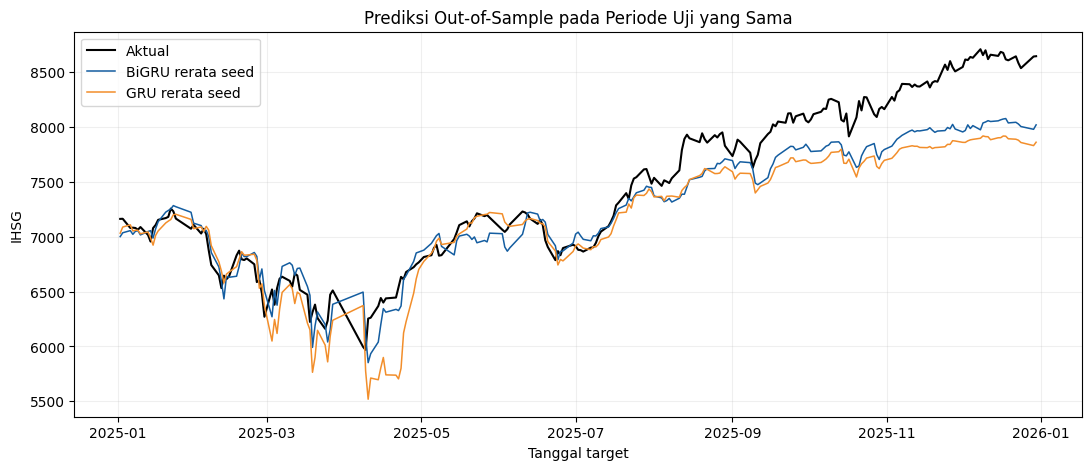

In [12]:
pred_long=pd.concat(predictions,ignore_index=True)
alignment_checks=pd.DataFrame([
 ["Jumlah tanggal per run sama", pred_long.groupby(["Model","Seed"]).size().nunique()==1],
 ["Tanggal unik per run", bool(pred_long.groupby(["Model","Seed"]).Date.apply(lambda x:x.is_unique).all())],
 ["Aktual identik antarrun", bool(pred_long.groupby("Date").Actual.nunique().max()==1)],
 ["Tidak ada prediksi kosong", bool(pred_long.Prediction.notna().all())],
],columns=["Pemeriksaan alignment","Lulus"])
display(alignment_checks.style.hide(axis="index").set_caption("OUTPUT 12A — Audit alignment prediksi"))
if not alignment_checks.Lulus.all(): raise AssertionError("Alignment prediksi gagal")

mean_pred=pred_long.groupby(["Date","Model"],as_index=False).agg(Actual=("Actual","first"),Prediction=("Prediction","mean"))
fig,ax=plt.subplots(figsize=(13,5)); actual_line=mean_pred.drop_duplicates("Date"); ax.plot(actual_line.Date,actual_line.Actual,color="black",lw=1.5,label="Aktual")
for kind,g in mean_pred.groupby("Model"): ax.plot(g.Date,g.Prediction,lw=1.1,label=f"{kind} rerata seed",color=colors[kind])
ax.set(title="Prediksi Out-of-Sample pada Periode Uji yang Sama",xlabel="Tanggal target",ylabel="IHSG"); ax.legend(); ax.grid(alpha=.2); plt.show()

## 13. Analisis Kritis dan Memo Integritas

In [13]:
gru=summary.set_index("Model").loc["GRU"]
bigru=summary.set_index("Model").loc["BiGRU"]
drop_pct=(gru.RMSE_mean/bigru.RMSE_mean-1)*100
unstable = bool((summary.RMSE_std / summary.RMSE_mean > .10).any())
hard_fail = not tensor_checks.Lulus.all() or not alignment_checks.Lulus.all()
status = "TIDAK SAH" if hard_fail else ("MERAGUKAN" if unstable or abs(drop_pct)>50 else "VALID")
reason = ("target/informasi masa depan atau alignment gagal" if hard_fail else
          "hasil tidak stabil atau selisih arsitektur sangat ekstrem sehingga perlu audit tambahan" if status=="MERAGUKAN" else
          "alignment t→t+1, scaler train-only, kontrol identik, dan uji lintas seed seluruhnya lolos")

critical = pd.DataFrame([
 ["Apakah backward BiGRU otomatis leakage?", "Tidak. Backward hanya membaca urutan di dalam jendela historis yang seluruhnya berakhir pada t."],
 ["Apa bukti leakage terkuat?", "Target t+1 atau fitur setelah t ditemukan dalam tensor input, atau scaler di-fit memakai validasi/test."],
 ["Bagaimana membaca penurunan GRU?", f"RMSE GRU berbeda {drop_pct:.2f}% relatif terhadap BiGRU. Selisih wajar dapat berasal dari kapasitas membaca hubungan dua arah di dalam jendela historis."],
 ["Apakah model terbaik sudah pasti?", "Tidak. Kesimpulan terbatas pada periode uji 2025, fitur, lookback, seed, dan hiperparameter notebook ini."],
],columns=["Pertanyaan audit","Analisis"])
display(critical.style.hide(axis="index").set_caption("OUTPUT 13A — Critical thinking"))

memo=pd.DataFrame({"Komponen":["Status integritas","Dasar keputusan","Selisih RMSE GRU vs BiGRU","Jumlah seed","Periode uji","Kesimpulan"],
                   "Isi":[status,reason,f"{drop_pct:.2f}%",len(SEED_LIST),"Target sepanjang 2025",f"Kinerja dinilai {status.lower()} dalam ruang lingkup eksperimen ini."]})
display(memo.style.hide(axis="index").set_caption("OUTPUT 13B — Memo integritas"))

Pertanyaan audit,Analisis
Apakah backward BiGRU otomatis leakage?,Tidak. Backward hanya membaca urutan di dalam jendela historis yang seluruhnya berakhir pada t.
Apa bukti leakage terkuat?,"Target t+1 atau fitur setelah t ditemukan dalam tensor input, atau scaler di-fit memakai validasi/test."
Bagaimana membaca penurunan GRU?,RMSE GRU berbeda 26.73% relatif terhadap BiGRU. Selisih wajar dapat berasal dari kapasitas membaca hubungan dua arah di dalam jendela historis.
Apakah model terbaik sudah pasti?,"Tidak. Kesimpulan terbatas pada periode uji 2025, fitur, lookback, seed, dan hiperparameter notebook ini."


Komponen,Isi
Status integritas,MERAGUKAN
Dasar keputusan,hasil tidak stabil atau selisih arsitektur sangat ekstrem sehingga perlu audit tambahan
Selisih RMSE GRU vs BiGRU,26.73%
Jumlah seed,3
Periode uji,Target sepanjang 2025
Kesimpulan,Kinerja dinilai meragukan dalam ruang lingkup eksperimen ini.


## 14. Bug Logika, Mitigasi, dan Ekspor

In [14]:
bug_log=pd.DataFrame([
 ["Random split", "Masa depan masuk train", "Split menurut Target_Date", "Dicegah"],
 ["Target ikut FEATURES", "Leakage langsung", "Daftar fitur eksplisit dan assertion", "Dicegah"],
 ["Scaler fit semua data", "Statistik test bocor", "Fit hanya train_rows", "Dicegah"],
 ["Window melewati target", "Future look-ahead", "Simpan Input_End dan Target_Date", "Dicegah"],
 ["shuffle=True", "Urutan pelatihan berubah", "shuffle=False", "Dicegah"],
 ["Satu seed", "Hasil kebetulan", "Tiga seed dan simpangan baku", "Dicegah"],
 ["BiGRU dianggap otomatis curang", "Kesimpulan metodologis salah", "Audit batas jendela, bukan nama layer", "Dikoreksi"],
 ["Parameter model berbeda", "BiGRU punya kapasitas lebih besar", "Laporkan count_params sebagai keterbatasan", "Dilaporkan"],
],columns=["Potensi bug","Dampak","Mitigasi","Status"])
display(bug_log.style.hide(axis="index").set_caption("OUTPUT 14 — Register bug dan logika"))

run_metrics.to_csv("metrik_run_gru_bigru.csv",index=False)
summary.to_csv("benchmark_card_gru_bigru.csv",index=False)
pred_long.to_csv("prediksi_aligned_gru_bigru.csv",index=False)
tensor_checks.to_csv("audit_tensor.csv",index=False)
memo.to_csv("memo_integritas.csv",index=False)
print("Ekspor selesai: 5 file CSV dibuat pada working directory Kaggle.")

Potensi bug,Dampak,Mitigasi,Status
Random split,Masa depan masuk train,Split menurut Target_Date,Dicegah
Target ikut FEATURES,Leakage langsung,Daftar fitur eksplisit dan assertion,Dicegah
Scaler fit semua data,Statistik test bocor,Fit hanya train_rows,Dicegah
Window melewati target,Future look-ahead,Simpan Input_End dan Target_Date,Dicegah
shuffle=True,Urutan pelatihan berubah,shuffle=False,Dicegah
Satu seed,Hasil kebetulan,Tiga seed dan simpangan baku,Dicegah
BiGRU dianggap otomatis curang,Kesimpulan metodologis salah,"Audit batas jendela, bukan nama layer",Dikoreksi
Parameter model berbeda,BiGRU punya kapasitas lebih besar,Laporkan count_params sebagai keterbatasan,Dilaporkan


Ekspor selesai: 5 file CSV dibuat pada working directory Kaggle.


## 15. Pedoman Kesimpulan

- **VALID**: seluruh tes alignment, tensor, scaler, dan prediksi lolos; variasi seed terkendali; perbedaan GRU dan BiGRU tidak ekstrem.
- **MERAGUKAN**: tes keras tidak menemukan leakage, tetapi hasil sangat tidak stabil atau selisih performa terlalu ekstrem. Tambahkan seed, periode uji, ablation fitur, dan pemeriksaan kode independen.
- **TIDAK SAH**: target `t+1`, informasi setelah `t`, statistik validasi/uji, atau tanggal yang salah ditemukan pada input.

Catatan penting: BiGRU membaca jendela historis dari dua arah internal. Hal itu sah selama seluruh elemen jendela tersedia pada waktu prediksi dan berakhir pada `t`. Arah backward baru menjadi masalah jika jendela memasukkan `t+1` atau data yang belum tersedia saat keputusan dibuat.